<a href="https://colab.research.google.com/github/bru379/ML/blob/main/HotEncoding/OneHotEncoder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# car price predictor model

This is for understanding linear regression and how can we handle the text values in data set

# importing libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn import linear_model



# load the data

In [3]:
df=pd.read_csv('carprices.csv')
df.head()

,Car Model,Mileage,Sell Price($),Age(yrs)
0,BMW X5,69000,18000,6
1,BMW X5,35000,34000,3
2,BMW X5,57000,26100,5
3,BMW X5,22500,40000,2
4,BMW X5,46000,31500,4


# analyse the data

In [4]:
df.info()
#check the colums data types and missed values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car Model      13 non-null     object
 1   Mileage        13 non-null     int64 
 2   Sell Price($)  13 non-null     int64 
 3   Age(yrs)       13 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 548.0+ bytes


## visulization

Here we are checking whetehr we can choose linear model or not ,THis Milage features act as linear with the dsta so we can use linear regression because it is in decreasing manner

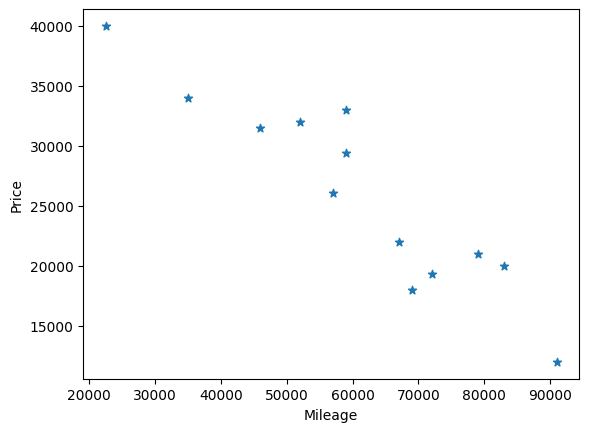

In [7]:
plt.scatter(df.Mileage,df['Sell Price($)'],marker='*')

plt.xlabel('Mileage')
plt.ylabel('Price')
plt.show()

## identify features

In [10]:
X=df.drop(['Sell Price($)'],axis=1 )
Y=df['Sell Price($)']

## convert text to numbers

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['Car Model']


#Apply different operations to different columns.
#here we are using only one transformer one hot encoder This is the actual operation


encoder = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), categorical_features)
    ],
    remainder='passthrough'
)

X = encoder.fit_transform(X)



<class 'sklearn.compose._column_transformer.ColumnTransformer'>


# split training and testing data

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)


## visualize the table
after the encoding

In [60]:

# get column names
column_nAME=encoder.get_feature_names_out()

df=pd.DataFrame(X,columns= column_nAME) # create as data frame from array

df

,encoder__Car Model_Audi A5,encoder__Car Model_BMW X5,encoder__Car Model_Mercedez Benz C class,remainder__Mileage,remainder__Age(yrs)
0,0.0,1.0,0.0,69000.0,6.0
1,0.0,1.0,0.0,35000.0,3.0
2,0.0,1.0,0.0,57000.0,5.0
3,0.0,1.0,0.0,22500.0,2.0
4,0.0,1.0,0.0,46000.0,4.0
5,1.0,0.0,0.0,59000.0,5.0
6,1.0,0.0,0.0,52000.0,5.0
7,1.0,0.0,0.0,72000.0,6.0
8,1.0,0.0,0.0,91000.0,8.0
9,0.0,0.0,1.0,67000.0,6.0


# create the model

In [39]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

# predict

In [36]:
model.predict([[0,0,1,45000,4]])


array([37420.01468968])

In [33]:
model.predict([[2,1,1,45000,4]])


array([34448.49430777])

In [34]:
model.predict([[1,0,0,86000,7]])

array([14423.04902682])

# evaluate

weused thre metrics methods to evaluate the score

In [50]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score # import the metrics


y_predict=model.predict(X_test)# actual model prediction using test values

mse=mean_squared_error(y_test,y_predict)
mae=mean_absolute_error(y_test,y_predict)
r2=r2_score(y_test,y_predict)
print(f"mean squared error : {mse}")
print(f"mean absolute error : {mae}")
print(f"r2 score : {r2}")

mean squared error : 2930463.906891652
mean absolute error : 1707.5062737165063
r2 score : 0.9166587399291384
